In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from matplotlib.patches import Patch

In [2]:
df = pd.read_csv('Mall_Customers.csv')

print("===== DATASET PREVIEW =====")
print(df.head(10))

===== DATASET PREVIEW =====
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72


In [3]:
print("===== DATASET STATISTICS =====")
print(df.describe().round(2))

===== DATASET STATISTICS =====
       CustomerID     Age  Annual Income (k$)  Spending Score (1-100)
count      200.00  200.00              200.00                  200.00
mean       100.50   38.85               60.56                   50.20
std         57.88   13.97               26.26                   25.82
min          1.00   18.00               15.00                    1.00
25%         50.75   28.75               41.50                   34.75
50%        100.50   36.00               61.50                   50.00
75%        150.25   49.00               78.00                   73.00
max        200.00   70.00              137.00                   99.00


In [4]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = MinMaxScaler()
data = scaler.fit_transform(features)

print("Normalized data sample:")
print(data[:5])

Normalized data sample:
[[0.01923077 0.         0.3877551 ]
 [0.05769231 0.         0.81632653]
 [0.03846154 0.00819672 0.05102041]
 [0.09615385 0.00819672 0.7755102 ]
 [0.25       0.01639344 0.39795918]]


In [5]:
som = MiniSom(x=10, y=10, input_len=3, sigma=1.0, learning_rate=0.5)
som.random_weights_init(data)
som.train_random(data, num_iteration=1000)

print("SOM Training Complete!")

SOM Training Complete!


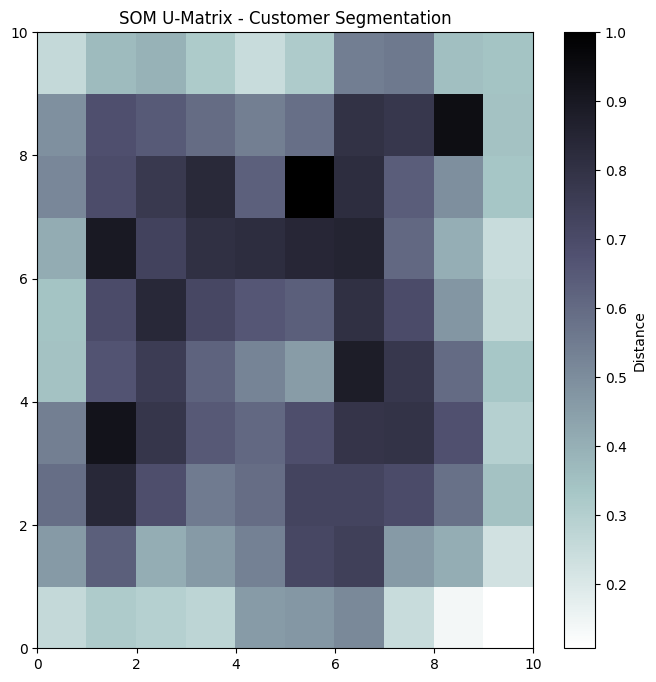

U-Matrix saved!


In [6]:
plt.figure(figsize=(8, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distance')
plt.title('SOM U-Matrix - Customer Segmentation')
plt.savefig('som_umatrix.png', dpi=150)
plt.show()

print("U-Matrix saved!")

In [7]:
winner_coordinates = np.array([som.winner(x) for x in data])

kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(winner_coordinates)

print("Cluster labels assigned!")
print(cluster_labels[:10])

Cluster labels assigned!
[0 0 3 0 3 0 0 0 0 0]


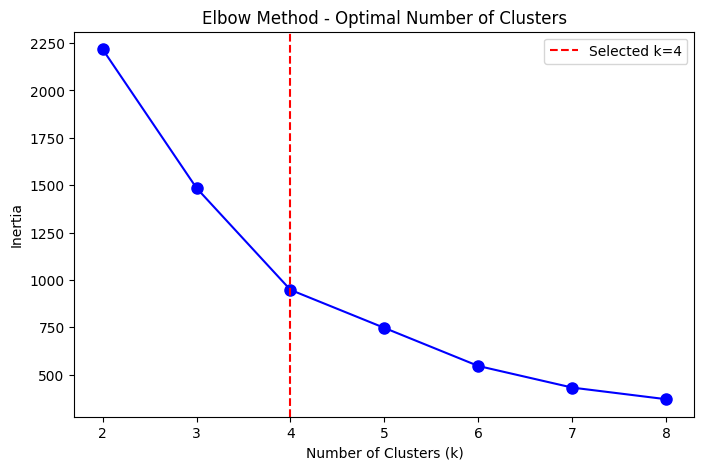

Elbow chart saved!


In [8]:
from sklearn.metrics import davies_bouldin_score

inertia = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(winner_coordinates)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.axvline(x=4, color='red', linestyle='--', label='Selected k=4')
plt.legend()
plt.savefig('elbow_method.png', dpi=150)
plt.show()

print("Elbow chart saved!")

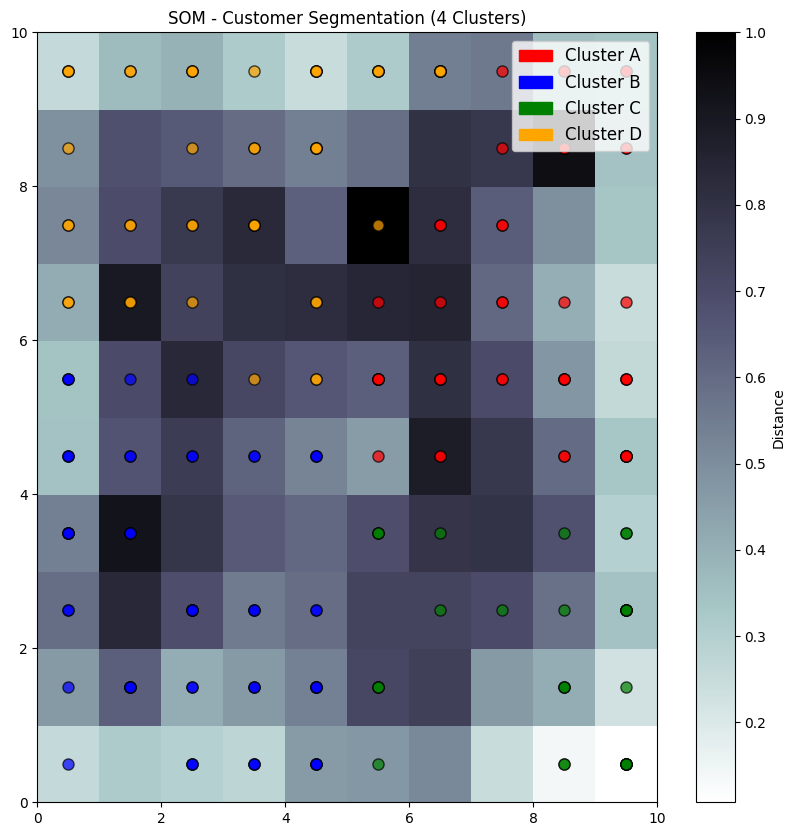

Final SOM map saved!


In [9]:
plt.figure(figsize=(10, 10))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distance')

colors = ['red', 'blue', 'green', 'orange']
cluster_names = ['Cluster A', 'Cluster B', 'Cluster C', 'Cluster D']

for i, x in enumerate(data):
    w = som.winner(x)
    plt.plot(w[0] + 0.5, w[1] + 0.5,
             'o',
             markerfacecolor=colors[cluster_labels[i]],
             markeredgecolor='k',
             markersize=8, alpha=0.7)

legend = [Patch(color=colors[i], label=cluster_names[i]) for i in range(4)]
plt.legend(handles=legend, loc='upper right', fontsize=12)
plt.title('SOM - Customer Segmentation (4 Clusters)')
plt.savefig('som_map_final.png', dpi=150)
plt.show()

print("Final SOM map saved!")

In [10]:
df['Cluster'] = cluster_labels

summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print("===== CLUSTER SUMMARY =====")
print(summary)

===== CLUSTER SUMMARY =====
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        46.7                34.2                    46.2
1        37.0                78.4                    61.1
2        47.6                60.5                    55.9
3        27.9                64.6                    37.1


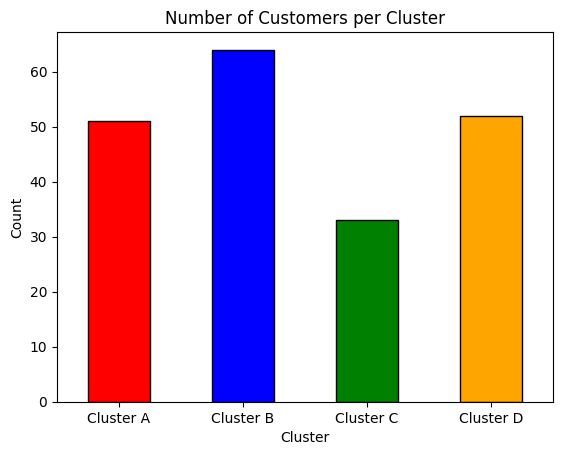

Cluster bar chart saved!


In [11]:
df['Cluster'].value_counts().sort_index().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(ticks=[0,1,2,3], labels=cluster_names, rotation=0)
plt.savefig('cluster_sizes.png', dpi=150)
plt.show()

print("Cluster bar chart saved!")